# Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import os

In [2]:
DATASET_PATH = "../data/1st_test"

### I. Preview Dataset

In [ ]:
df = pd.read_csv(os.path.join(DATASET_PATH, "2003.10.22.12.06.24"), sep = "\t", header = None)
df.columns = ["Bearing 1 (X)", "Bearing 1 (Y)", "Bearing 2 (X)", "Bearing 2 (Y)", "Bearing 3 (X)", "Bearing 3 (Y)", "Bearing 4 (X)", "Bearing 4 (Y)"]
df.head()

,Bearing 1 (X),Bearing 1 (Y),Bearing 2 (X),Bearing 2 (Y),Bearing 3 (X),Bearing 3 (Y),Bearing 4 (X),Bearing 4 (Y)
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


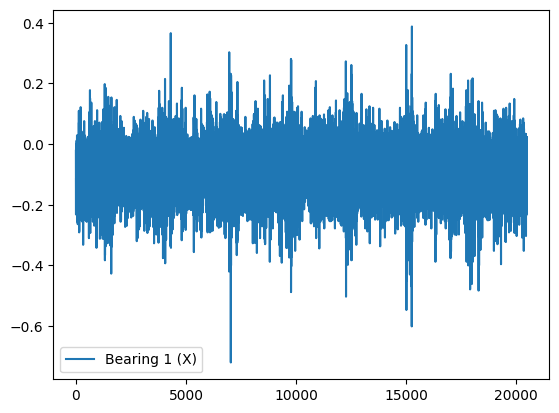

In [6]:
df[["Bearing 1 (X)"]].plot()
plt.show()

### II. Merge Dataset

In [9]:
df = []

for file_name in sorted(os.listdir(DATASET_PATH)):
    dataset = pd.read_csv(os.path.join(DATASET_PATH, file_name), sep = "\t", header = None)

    features = {}
    features["timestamp"] = file_name

    for i, column in enumerate(dataset.columns):
        X = dataset[column]
        prefix = f"bearing_{i // 2 + 1}_({'x' if i % 2 == 0 else 'y'})"

        features[f"{prefix}_mean_absolute"] = np.mean(np.abs(X))
        features[f"{prefix}_std"] = np.std(X)
        features[f"{prefix}_skewness"] = scipy.stats.skew(X)
        features[f"{prefix}_kurtosis"] = scipy.stats.kurtosis(X)
        features[f"{prefix}_rms"] = np.sqrt(np.mean(X ** 2))
        features[f"{prefix}_crest_factor"] = np.max(np.abs(X)) / np.sqrt(np.mean(X ** 2))

    df.append(features)

df = pd.DataFrame(df)
df["timestamp"] = pd.to_datetime(df["timestamp"], format = "%Y.%m.%d.%H.%M.%S")
df = df.sort_values("timestamp").set_index("timestamp")
df.head()

,bearing_1_(x)_mean_absolute,bearing_1_(x)_std,bearing_1_(x)_skewness,bearing_1_(x)_kurtosis,bearing_1_(x)_rms,bearing_1_(x)_crest_factor,bearing_1_(y)_mean_absolute,bearing_1_(y)_std,bearing_1_(y)_skewness,bearing_1_(y)_kurtosis,...,bearing_4_(x)_skewness,bearing_4_(x)_kurtosis,bearing_4_(x)_rms,bearing_4_(x)_crest_factor,bearing_4_(y)_mean_absolute,bearing_4_(y)_std,bearing_4_(y)_skewness,bearing_4_(y)_kurtosis,bearing_4_(y)_rms,bearing_4_(y)_crest_factor
timestamp,,,,,,,,,,,,,,,,,,,,,
2003-10-22 12:06:24,0.104144,0.081122,-0.029993,1.069163,0.124614,5.777850,0.100250,0.070648,0.220116,3.065884,...,0.046609,0.790250,0.109020,3.788279,0.099515,0.066380,0.008295,1.807990,0.115267,4.086150
2003-10-22 12:09:13,0.103652,0.079515,-0.070075,1.161552,0.123811,5.282236,0.099853,0.069529,0.126498,2.001016,...,0.085164,1.234703,0.108900,3.856767,0.093585,0.064744,-0.053792,1.873189,0.109208,5.741343
2003-10-22 12:14:13,0.105036,0.080217,-0.041646,0.986286,0.125246,4.974196,0.101540,0.069464,0.151050,1.968951,...,0.009609,0.924708,0.110319,3.589583,0.098300,0.065253,0.047138,1.429695,0.113696,5.286029
2003-10-22 12:19:13,0.104898,0.080825,0.005162,1.034294,0.125197,4.776455,0.101570,0.071265,0.099494,1.745370,...,-0.037259,0.652667,0.111037,3.539356,0.098600,0.066301,0.021106,1.378184,0.114413,4.588643
2003-10-22 12:24:13,0.104776,0.082034,-0.060196,1.110164,0.125618,4.959475,0.102188,0.072153,0.095884,1.181160,...,0.036514,0.635576,0.110190,3.412278,0.098468,0.066279,0.008626,1.497653,0.114258,4.568625


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bearing_1_(x)_mean_absolute,2156.0,0.127485,0.006072,0.103652,0.127832,0.128904,0.129828,0.142146
bearing_1_(x)_std,2156.0,0.098572,0.005344,0.079413,0.096967,0.099051,0.101151,0.129741
bearing_1_(x)_skewness,2156.0,-0.038619,0.030227,-0.137095,-0.058606,-0.038394,-0.017576,0.071569
bearing_1_(x)_kurtosis,2156.0,0.998084,0.197341,0.279632,0.867872,0.995836,1.123880,1.699493
bearing_1_(x)_rms,2156.0,0.152221,0.007184,0.123811,0.152211,0.153733,0.155258,0.174975
bearing_1_(x)_crest_factor,2156.0,4.774991,0.500901,3.667271,4.407684,4.712527,5.063920,7.123804
bearing_1_(y)_mean_absolute,2156.0,0.124183,0.006244,0.099853,0.124815,0.125841,0.126581,0.132984
bearing_1_(y)_std,2156.0,0.088981,0.005293,0.069301,0.087883,0.090198,0.091836,0.106988
bearing_1_(y)_skewness,2156.0,0.066450,0.040887,-0.072625,0.039782,0.064548,0.093124,0.220840
bearing_1_(y)_kurtosis,2156.0,1.103727,0.308080,0.265705,0.891609,1.067158,1.273411,3.065884


In [11]:
df.to_csv(os.path.join(DATASET_PATH, "test_1_clean.csv"))